# Validation Results Inspection

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import sys
import os

sys.path.append("..")

os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [12]:
import numpy as np
import matplotlib.pyplot as plt

import re
from collections import defaultdict

from gyaradax.plot_utils import (
    plot_flux_trace,
    plot_spectra,
    plot_growth_rates,
    plot_growth_snapshots,
)
from gyaradax.params import load_config
from gyaradax.utils import load_geometry

In [13]:
adiabatic_dirs = sorted([d for d in os.listdir("..") if d.startswith("validation_outputs_")])
kinetic_dirs = sorted([d for d in os.listdir("..") if d.startswith("validation_kinetic_")])
print(f"adiabatic: {adiabatic_dirs}")
print(f"kinetic: {kinetic_dirs}")


adiabatic: ['validation_outputs_iteration_13a', 'validation_outputs_iteration_13b', 'validation_outputs_iteration_13c', 'validation_outputs_iteration_200a', 'validation_outputs_iteration_200b', 'validation_outputs_iteration_200c']
kinetic: ['validation_kinetic_v3_kiteration_991_half_rlt']


## 1. Adiabatic Flux Comparison

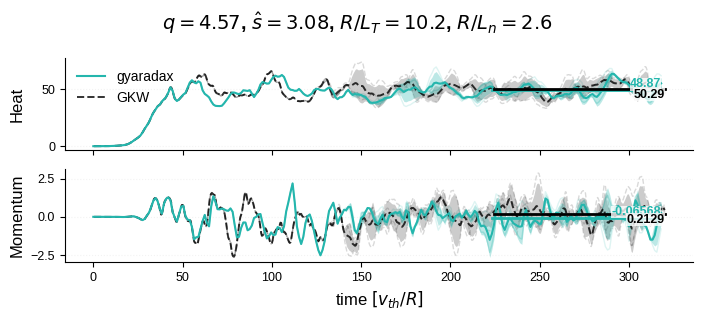

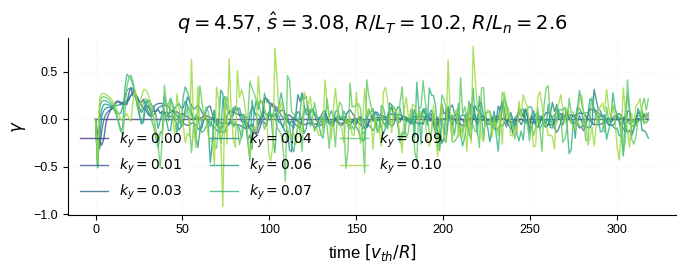

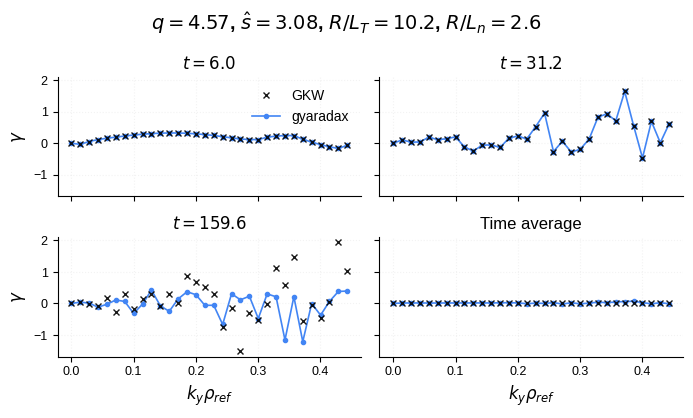

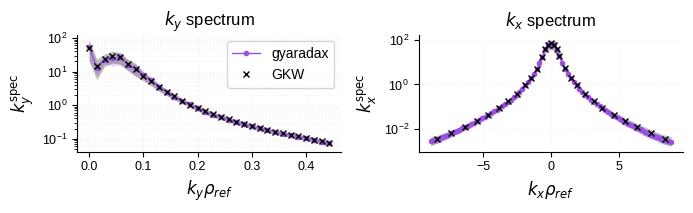

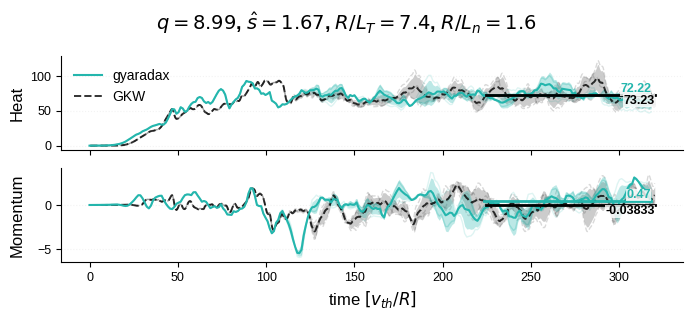

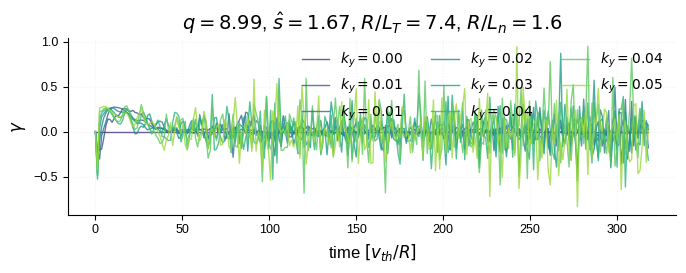

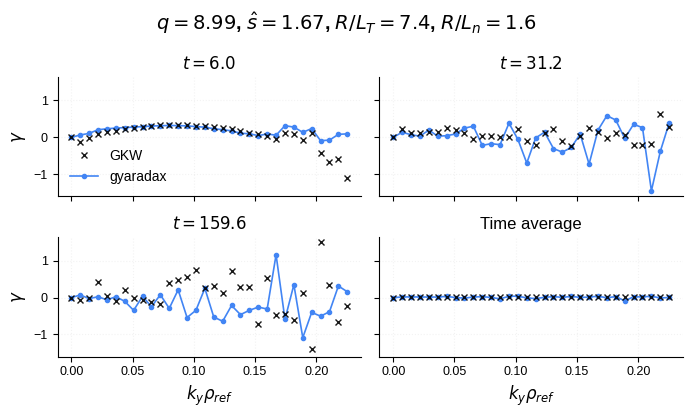

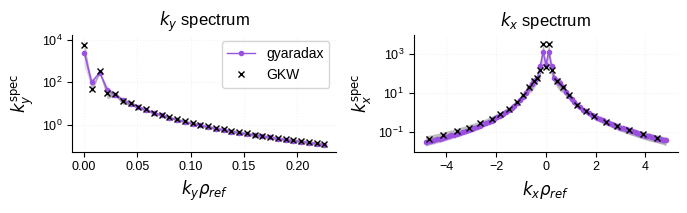

In [14]:
os.makedirs("figs", exist_ok=True)

# shade_mode for spectra error bounds:
#   "none"        — no shading (original behavior)
#   "trajectory"  — std across runs only (time-averaged per run, then std across runs)
#   "time"        — std across time only (pool all runs, compute std over time axis)
#   "both"        — std across both time and trajectory (flatten runs+time, then std)
SHADE_MODE = "both"

grouped_adiabatic = defaultdict(list)
for out_dir in adiabatic_dirs:
    config_name = out_dir.replace("validation_outputs_", "")
    base_name = re.sub(r"[a-z]$", "", config_name)
    grouped_adiabatic[base_name].append(out_dir)
    
for base_name, dirs in grouped_adiabatic.items():
    all_fluxes, all_growths, all_times = [], [], []
    all_kx_specs, all_ky_specs = [], []
    
    for out_dir in dirs:
        path = os.path.join("..", out_dir)
        flux_path = os.path.join(path, "fluxes.npz")
        growth_path = os.path.join(path, "growth.npz")
        
        if not os.path.exists(flux_path) or not os.path.exists(growth_path):
            continue

        all_fluxes.append(np.load(flux_path)["fluxes"])
        gdata = np.load(growth_path)
        all_times.append(gdata["time"])
        all_growths.append(gdata["growth"])

        kx_spec_path = os.path.join(path, "kxspec.npz")
        ky_spec_path = os.path.join(path, "kyspec.npz")
        if os.path.exists(kx_spec_path) and os.path.exists(ky_spec_path):
            all_kx_specs.append(np.load(kx_spec_path)["kx_spec"])
            all_ky_specs.append(np.load(ky_spec_path)["ky_spec"])

    if not all_fluxes:
        continue
    
    min_len = min(len(t) for t in all_times)
    sim_time = all_times[0][:min_len]
    sim_flux = np.stack([f[:min_len].T for f in all_fluxes])
    sim_growth = np.stack([g[:min_len] for g in all_growths])
    sim_growth_mean = np.mean(sim_growth, axis=0)

    ref_time, ref_fluxes, ref_fluxes_plot = None, None, None
    kx, ky = None, None
    title = base_name
    ref_dir = None
    
    all_ref_times = []
    all_ref_fluxes = []
    all_ref_kx_specs = []
    all_ref_ky_specs = []
    all_ref_dirs = []
    
    for out_dir in dirs:
        config_name = out_dir.replace("validation_outputs_", "")
        c_path = os.path.join("..", "configs", f"{config_name}.yaml")
        if os.path.exists(c_path):
            cfg = load_config(c_path)
            rdir = cfg.run.data_dir
            all_ref_dirs.append(rdir)
            if ref_dir is None:
                ref_dir = rdir
                
            if os.path.exists(os.path.join(rdir, "time.dat")) and os.path.exists(os.path.join(rdir, "fluxes.dat")):
                all_ref_times.append(np.loadtxt(os.path.join(rdir, "time.dat")))
                all_ref_fluxes.append(np.loadtxt(os.path.join(rdir, "fluxes.dat")).T)

            # collect ref spectra from each GKW run
            ref_kx_path = os.path.join(rdir, "kxspec")
            ref_ky_path = os.path.join(rdir, "kyspec")
            if os.path.exists(ref_kx_path) and os.path.exists(ref_ky_path):
                all_ref_kx_specs.append(np.loadtxt(ref_kx_path))
                all_ref_ky_specs.append(np.loadtxt(ref_ky_path))

    if all_ref_times:
        ref_min_len = min(len(t) for t in all_ref_times)
        ref_time = all_ref_times[0][:ref_min_len]
        if len(all_ref_fluxes) > 1:
            ref_fluxes = np.stack([f[:, :ref_min_len] for f in all_ref_fluxes])
            ref_fluxes_plot = ref_fluxes[:, [1, 2], :]
        else:
            ref_fluxes = all_ref_fluxes[0][:, :ref_min_len]
            ref_fluxes_plot = ref_fluxes[[1, 2], :]

    if ref_dir:
        geom = load_geometry(ref_dir)
        kx = np.asarray(geom["kxrh"])
        ky = np.asarray(geom["krho"])

        q = float(geom["q"])
        shat = float(geom["shat"])
        rlt = float(np.asarray(geom["rlt"]).flat[0])
        rln = float(np.asarray(geom["rln"]).flat[0])
        title = (
            rf"$q={q:.2f}$, $\hat{{s}}={shat:.2f}$, " rf"$R/L_T={rlt:.1f}$, $R/L_n={rln:.1f}$"
        )

    fig = plot_flux_trace(
        sim_time,
        sim_flux[:, [1, 2], :],
        ref_time=ref_time,
        ref_fluxes=ref_fluxes_plot,
        labels=["Heat", "Momentum"],
        title=title,
        show_average=True
    )
    fig.savefig(f"figs/fluxes_{base_name}.pdf")

    if sim_growth_mean.ndim == 2 and ky is not None:
        ref_time_dat = None
        if ref_dir:
            t_path = os.path.join(ref_dir, "time.dat")
            if os.path.exists(t_path):
                rd = np.loadtxt(t_path)
                if rd.ndim == 2 and rd.shape[1] >= 2:
                    ref_time_dat = rd

        fig_gr = plot_growth_rates(
            sim_time,
            sim_growth_mean,
            ky=ky,
            ref_time=ref_time_dat,
            title=title,
        )
        fig_gr.savefig(f"figs/growth_{base_name}.pdf")

        ref_growth_dat, ref_time_1d = None, None
        if ref_dir:
            gdat_path = os.path.join(ref_dir, "growth.dat")
            tdat_path = os.path.join(ref_dir, "time.dat")
            if os.path.exists(gdat_path) and os.path.exists(tdat_path):
                ref_growth_dat = np.loadtxt(gdat_path)
                ref_time_1d = np.loadtxt(tdat_path)
                if ref_time_1d.ndim == 2:
                    ref_time_1d = ref_time_1d[:, 0]

        fig_snap = plot_growth_snapshots(
            ky,
            sim_growth_mean,
            sim_time,
            ref_growth=ref_growth_dat,
            ref_time=ref_time_1d,
            title=title,
        )
        fig_snap.savefig(f"figs/growth_snap_{base_name}.pdf")

    if all_kx_specs and all_ky_specs and kx is not None:
        avg_count = 80
        min_spec_len = min(len(s) for s in all_kx_specs)
        
        # (n_runs, n_windows, nk)
        sim_kx_spec = np.stack([s[:min_spec_len] for s in all_kx_specs])
        sim_ky_spec = np.stack([s[:min_spec_len] for s in all_ky_specs])
        
        if sim_kx_spec.shape[-1] != len(kx) or sim_ky_spec.shape[-1] != len(ky):
            continue

        # time-averaged mean per run: (n_runs, nk)
        kx_per_run = np.mean(sim_kx_spec[:, -avg_count:, :], axis=1)
        ky_per_run = np.mean(sim_ky_spec[:, -avg_count:, :], axis=1)
        # grand mean: (nk,)
        kx_spec_avg = np.mean(kx_per_run, axis=0)
        ky_spec_avg = np.mean(ky_per_run, axis=0)

        # compute std based on shade_mode
        kx_spec_std, ky_spec_std = None, None
        if SHADE_MODE == "trajectory":
            kx_spec_std = np.std(kx_per_run, axis=0)
            ky_spec_std = np.std(ky_per_run, axis=0)
        elif SHADE_MODE in ("time", "both"):
            kx_pooled = sim_kx_spec[:, -avg_count:, :].reshape(-1, len(kx))
            ky_pooled = sim_ky_spec[:, -avg_count:, :].reshape(-1, len(ky))
            kx_spec_std = np.std(kx_pooled, axis=0)
            ky_spec_std = np.std(ky_pooled, axis=0)

        # ref spectra: collect from all GKW runs (each has its own data_dir)
        ref_kx_spec, ref_ky_spec = None, None
        ref_kx_spec_std, ref_ky_spec_std = None, None
        if all_ref_kx_specs and all_ref_ky_specs:
            # time-averaged per ref run: (n_ref_runs, nk)
            ref_kx_per_run = np.stack([np.mean(s[-avg_count * 3 :], axis=0) for s in all_ref_kx_specs])
            ref_ky_per_run = np.stack([np.mean(s[-avg_count * 3 :], axis=0) for s in all_ref_ky_specs])
            ref_kx_spec = np.mean(ref_kx_per_run, axis=0)
            ref_ky_spec = np.mean(ref_ky_per_run, axis=0)

            if SHADE_MODE == "trajectory" and len(all_ref_kx_specs) > 1:
                ref_kx_spec_std = np.std(ref_kx_per_run, axis=0)
                ref_ky_spec_std = np.std(ref_ky_per_run, axis=0)
            elif SHADE_MODE in ("time", "both"):
                # pool time windows from all ref runs
                ref_kx_pooled = np.concatenate([s[-avg_count * 3 :] for s in all_ref_kx_specs], axis=0)
                ref_ky_pooled = np.concatenate([s[-avg_count * 3 :] for s in all_ref_ky_specs], axis=0)
                ref_kx_spec_std = np.std(ref_kx_pooled, axis=0)
                ref_ky_spec_std = np.std(ref_ky_pooled, axis=0)

        fig_spec = plot_spectra(
            kx=kx,
            ky=ky,
            kx_spec=kx_spec_avg,
            ky_spec=ky_spec_avg,
            ref_kx_spec=ref_kx_spec,
            ref_ky_spec=ref_ky_spec,
            kx_spec_std=kx_spec_std,
            ky_spec_std=ky_spec_std,
            ref_kx_spec_std=ref_kx_spec_std,
            ref_ky_spec_std=ref_ky_spec_std,
        )
        fig_spec.savefig(f"figs/spectra_{base_name}.pdf")

## 2. Kinetic Electron Flux Comparison

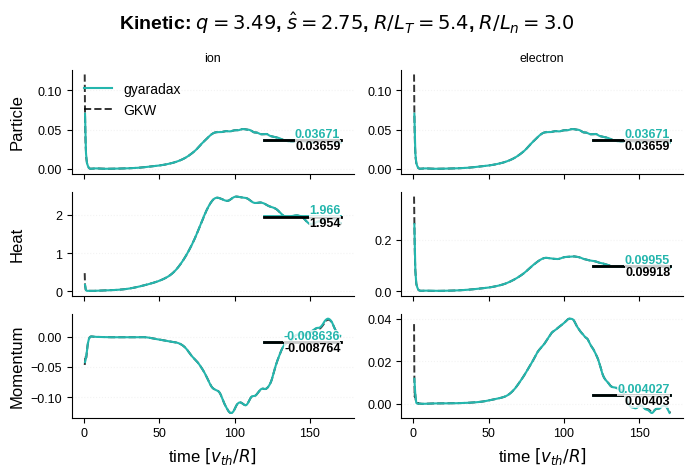

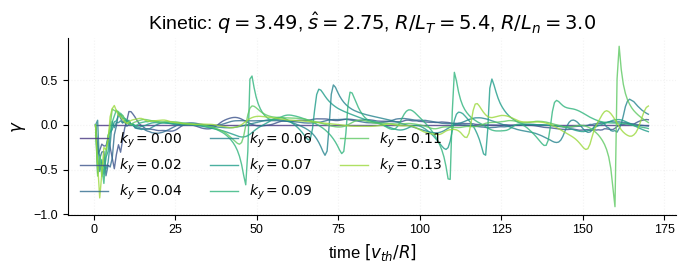

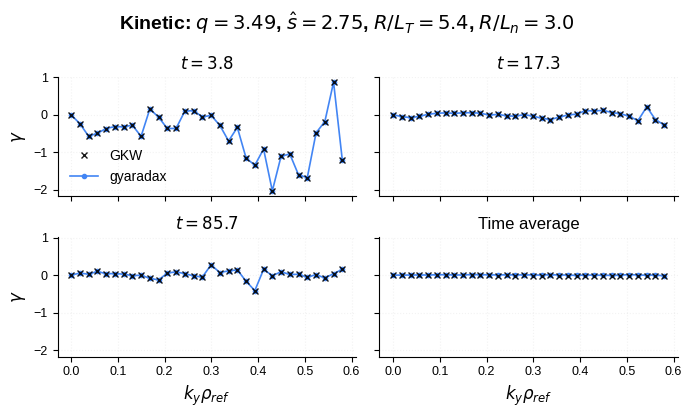

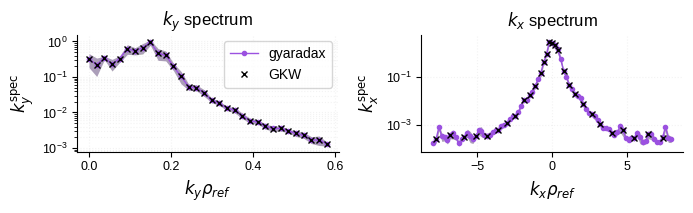

In [15]:
KINETIC_REF_DIR = "/restricteddata/ukaea/gyrokinetics/raw/kinetic_electrons"

for out_dir in kinetic_dirs:
    path = os.path.join("..", out_dir)
    case_name = out_dir.replace("validation_kinetic_", "")

    # resolve ref_dir from the yaml config (folder names don't match 1:1)
    config_path = os.path.join("..", "configs", f"{case_name}.yaml")
    if os.path.exists(config_path):
        cfg = load_config(config_path)
        ref_dir = cfg.run.data_dir
    else:
        ref_dir = os.path.join(KINETIC_REF_DIR, case_name)

    flux_path = os.path.join(path, "fluxes.npz")
    growth_path = os.path.join(path, "growth.npz")

    if not os.path.exists(flux_path) or not os.path.exists(growth_path):
        print(f"skipping {out_dir}: missing .npz files")
        continue

    # fluxes shape: (n_entries, nsp, 3) -> interleave to (6, n_entries)
    # order: [pflux_i, eflux_i, vflux_i, pflux_e, eflux_e, vflux_e]
    fluxes_data = np.load(flux_path)["fluxes"]
    sim_times = np.load(growth_path)["time"]
    sim_fluxes = fluxes_data.reshape(-1, 6).T

    # growth rates
    gdata = np.load(growth_path)
    sim_growth = gdata["growth"]

    ref_time = np.loadtxt(os.path.join(ref_dir, "time.dat"))[1:]
    ref_fluxes = np.loadtxt(os.path.join(ref_dir, "fluxes.dat"))[1:].T  # (6, n_ref)

    # build title from geometry scalars
    geom = load_geometry(ref_dir)
    q = float(geom["q"])
    shat = float(geom["shat"])
    rlt = float(np.asarray(geom["rlt"]).flat[0])
    rln = float(np.asarray(geom["rln"]).flat[0])
    kx = np.asarray(geom["kxrh"])
    ky = np.asarray(geom["krho"])
    title = (
        rf"Kinetic: $q={q:.2f}$, $\hat{{s}}={shat:.2f}$, "
        rf"$R/L_T={rlt:.1f}$, $R/L_n={rln:.1f}$"
    )

    # all 3 fluxes, split by species (ion | electron columns)
    fig = plot_flux_trace(
        sim_times,
        sim_fluxes,
        ref_time=ref_time,
        ref_fluxes=ref_fluxes,
        labels=["Particle", "Heat", "Momentum"],
        title=title,
        n_species=2,
        show_average=True
    )
    fig.savefig(f"figs/kinetic_fluxes_{case_name}.pdf")
    plt.show()

    # growth rate diagnostics (matching adiabatic section)
    if sim_growth.ndim == 2 and ky is not None:
        ref_time_dat = None
        t_path = os.path.join(ref_dir, "time.dat")
        if os.path.exists(t_path):
            rd = np.loadtxt(t_path)
            if rd.ndim == 2 and rd.shape[1] >= 2:
                ref_time_dat = rd

        fig_gr = plot_growth_rates(
            sim_times,
            sim_growth,
            ky=ky,
            ref_time=ref_time_dat,
            title=title,
        )
        fig_gr.savefig(f"figs/kinetic_growth_{case_name}.pdf")
        plt.show()

        ref_growth_dat, ref_time_1d = None, None
        gdat_path = os.path.join(ref_dir, "growth.dat")
        tdat_path = os.path.join(ref_dir, "time.dat")
        if os.path.exists(gdat_path) and os.path.exists(tdat_path):
            ref_growth_dat = np.loadtxt(gdat_path)
            ref_time_1d = np.loadtxt(tdat_path)
            if ref_time_1d.ndim == 2:
                ref_time_1d = ref_time_1d[:, 0]

        fig_snap = plot_growth_snapshots(
            ky,
            sim_growth,
            sim_times,
            ref_growth=ref_growth_dat,
            ref_time=ref_time_1d,
            title=title,
        )
        fig_snap.savefig(f"figs/kinetic_growth_snap_{case_name}.pdf")
        plt.show()

    # spectra if available
    kx_spec_path = os.path.join(path, "kxspec.npz")
    ky_spec_path = os.path.join(path, "kyspec.npz")
    if os.path.exists(kx_spec_path) and os.path.exists(ky_spec_path):
        sim_kx_raw = np.load(kx_spec_path)["kx_spec"]
        sim_ky_raw = np.load(ky_spec_path)["ky_spec"]
        avg_count = min(80, len(sim_kx_raw))
        kx_spec_avg = np.mean(sim_kx_raw[-avg_count:], axis=0)
        ky_spec_avg = np.mean(sim_ky_raw[-avg_count:], axis=0)

        # std over time for single-run kinetic case
        kx_spec_std, ky_spec_std = None, None
        if SHADE_MODE in ("time", "both"):
            kx_spec_std = np.std(sim_kx_raw[-avg_count:], axis=0)
            ky_spec_std = np.std(sim_ky_raw[-avg_count:], axis=0)

        ref_kx_spec, ref_ky_spec = None, None
        ref_kx_spec_std, ref_ky_spec_std = None, None
        ref_kx_path = os.path.join(ref_dir, "kxspec")
        ref_ky_path = os.path.join(ref_dir, "kyspec")
        if os.path.exists(ref_kx_path) and os.path.exists(ref_ky_path):
            ref_kx_raw = np.loadtxt(ref_kx_path)[-avg_count * 3 :]
            ref_ky_raw = np.loadtxt(ref_ky_path)[-avg_count * 3 :]
            ref_kx_spec = np.mean(ref_kx_raw, axis=0)
            ref_ky_spec = np.mean(ref_ky_raw, axis=0)
            if SHADE_MODE in ("time", "both"):
                ref_kx_spec_std = np.std(ref_kx_raw, axis=0)
                ref_ky_spec_std = np.std(ref_ky_raw, axis=0)

        fig_spec = plot_spectra(
            kx=kx,
            ky=ky,
            kx_spec=kx_spec_avg,
            ky_spec=ky_spec_avg,
            ref_kx_spec=ref_kx_spec,
            ref_ky_spec=ref_ky_spec,
            kx_spec_std=kx_spec_std,
            ky_spec_std=ky_spec_std,
            ref_kx_spec_std=ref_kx_spec_std,
            ref_ky_spec_std=ref_ky_spec_std,
        )
        fig_spec.savefig(f"figs/kinetic_spectra_{case_name}.pdf")

## 3. Statistical Validation

Quantitative comparison of gyaradax vs GKW using:
- **Spectra**: KS test, Pearson correlation, relative $L_2$ error on time-averaged $k_x$ and $k_y$ spectra
- **Growth rates**: Mean $\pm$ std of the time-averaged growth rate profile in a parametric window
- **Flux averages**: Jensen-Shannon divergence and 2-Wasserstein distance between Gaussian-fitted flux distributions, plus mean $\pm$ std

In [18]:
from gyaradax.validation_stats import compare_config, aggregate_results, results_to_latex

AVG_SIM = 80
AVG_REF = 240

# discover all validation output directories (project root + scan/)
# SCAN_DIRS = [os.path.join("..", "scan")]
SCAN_DIRS = [".."]

all_out_dirs = []
for scan_root in SCAN_DIRS:
    if not os.path.isdir(scan_root):
        continue
    for d in sorted(os.listdir(scan_root)):
        if d.startswith("validation_outputs_"):
            all_out_dirs.append((scan_root, d))

# group by base config name (strip trailing letter suffix)
grouped = defaultdict(list)
for scan_root, out_dir in all_out_dirs:
    config_name = out_dir.replace("validation_outputs_", "")
    base_name = re.sub(r"[a-z]$", "", config_name)
    grouped[base_name].append((scan_root, out_dir, config_name))

all_stats = {}

for base_name, entries in grouped.items():
    sim_out_dirs = []
    ref_dir = None

    for scan_root, out_dir, config_name in entries:
        path = os.path.join(scan_root, out_dir)

        if not os.path.exists(os.path.join(path, "fluxes.npz")):
            continue
        sim_out_dirs.append(path)

        if ref_dir is None:
            for cfg_dir in ("configs", os.path.join("configs", "sweep")):
                c_path = os.path.join("..", cfg_dir, f"{config_name}.yaml")
                if os.path.exists(c_path):
                    cfg = load_config(c_path)
                    ref_dir = cfg.run.data_dir
                    break

    if not sim_out_dirs or ref_dir is None:
        continue

    result = compare_config(sim_out_dirs, ref_dir, avg_sim=AVG_SIM, avg_ref=AVG_REF)
    if result:
        all_stats[base_name] = result

print(f"computed stats for {len(all_stats)} configurations:")
for name in sorted(all_stats):
    n_runs = len(grouped[name])
    print(f"  {name}: {n_runs} run(s)")

computed stats for 2 configurations:
  iteration_13: 3 run(s)
  iteration_200: 3 run(s)


In [20]:
from IPython.display import display, Latex, Markdown
from gyaradax.validation_stats import results_to_markdown

aggregated = aggregate_results(all_stats)

# markdown table (rendered in notebook)
md_str = results_to_markdown(aggregated, per_config=all_stats)
display(Markdown(md_str))

# latex table (for paper)
latex_str = results_to_latex(aggregated, per_config=all_stats)
print(latex_str)

**Statistical validation: gyaradax vs GKW** (aggregated over 2 trajectories)

| | KS stat (p) | Pearson r (p) | Log rel. L2 |
|---|---|---|---|
| ky spectrum | 0.068 +/- 0.021 (< 0.001) | 0.991 +/- 0.006 (< 0.001) | 0.054 +/- 0.015 |
| kx spectrum | 0.056 +/- 0.016 (< 0.001) | 0.988 +/- 0.002 (< 0.001) | 0.060 +/- 0.037 |

| | gamma_sim +/- std | gamma_ref +/- std |
|---|---|---|
| Growth rate | 0.0067 +/- 0.0057 (0.0335 +/- 0.0052) | -0.0000 +/- 0.0023 (0.5516 +/- 0.0343) |

| | JSD | W2 | sim mean +/- std | ref mean +/- std |
|---|---|---|---|---|
| Gamma_p | 0.1869 +/- 0.1630 | 0.0000 | 0.0000 | 0.0000 |
| Q | 0.1812 +/- 0.0233 | 6.5428 +/- 0.6394 | 60.5490 +/- 11.6752 | 58.4664 +/- 8.1239 |
| Pi | 0.5668 +/- 0.0376 | 1.1915 +/- 0.1418 | 0.2022 +/- 0.2678 | 0.1251 +/- 0.4131 |

\begin{table}[h]
\centering
\caption{Statistical validation: gyaradax vs GKW (aggregated over $2$ trajectories)}
\label{tab:validation_stats}
\begin{tabular}{l c c c}
\toprule
 & KS stat ($p$) & Pearson $r$ ($p$) & Log rel.\ $L_2$ \\
\midrule
$k_y$ spectrum & $0.068 \pm 0.021$ ($< 0.001$) & $0.991 \pm 0.006$ ($< 0.001$) & $0.054 \pm 0.015$ \\
$k_x$ spectrum & $0.056 \pm 0.016$ ($< 0.001$) & $0.988 \pm 0.002$ ($< 0.001$) & $0.060 \pm 0.037$ \\
\midrule
 & $\bar{\gamma}_{\mathrm{sim}} \pm \sigma$ & $\bar{\gamma}_{\mathrm{ref}} \pm \sigma$ & \\
\midrule
Growth rate & $0.0067 \pm 0.0057$ ($0.0335 \pm 0.0052$) & $-0.0000 \pm 0.0023$ ($0.5516 \pm 0.0343$) & \\
\midrule
 & JSD & $W_2$ & $\mu_{\mathrm{sim}} \pm \sigma$ vs $\mu_{\mathrm{ref}} \pm \sigma$ \\
\midrule
$\Gamma_p$ & $0.1869 \pm 0.1630$ & $0.0000$ & $0.0000$ vs $0.0000$ \\
$Q$ & $0.1812 \pm 0.0233$ & $6.5428 \pm 0.6394$ & $60.5490 \pm 11.6752$ vs $58.4664 \pm 8.1239$ \\
$\Pi$ & $0.5668 \pm 0.0376$ & $1.1915 \pm 0.1418$ & $0.2022 \pm

### Interpretation

- **KS test**: Low statistic ($\lesssim 0.1$) and high $p$-value ($> 0.05$) indicate consistent spectral shapes. Note: discrete k-grids limit the test's resolution.
- **Pearson $r$**: Values close to 1.0 confirm spectral shape agreement; $p < 0.05$ is significant.
- **Relative $L_2$**: Amplitude-weighted distance; values $\lesssim 0.2$ indicate good quantitative match.
- **Growth rate**: Mean $\pm$ std over the parametric window. Agreement is assessed by overlap of error bars.
- **JSD**: Symmetric KL-based divergence between Gaussian-fitted flux distributions. Values near 0 indicate identical distributions.
- **$W_2$**: 2-Wasserstein distance in physical units; measures combined shift in mean and spread.